> ### Corrected 2026-08-16 — the numbers in this notebook are superseded
>
> This notebook was executed against **2867 clips / 31 "birds"**. That count was filename
> prefixes, not individuals: `HPiHPi4748` and `HpiHpi4748` are one bird under two
> capitalizations, and four `Unknown*` prefixes (53 clips) are catch-alls. The corrected set is
> **2814 clips / 26 birds**, which moves the probe from 0.821 to **0.811** and the best k from
> 20 to **16**.
>
> Two further caveats, both detailed in `README.md`:
>
> - **No bird is held out of pretraining.** 99.5% of these clips were cut from the same 120
>   recordings the encoder was pretrained on, so "leave-birds-out" constrains the probe, not the
>   model. Read the accuracy as an upper bound for a genuinely new individual.
> - A **random split** scores 0.925 on the same features (+0.114). Check how a number was split
>   before comparing it to anything.
>
> `ZF_HuBERT_Replication.ipynb` is executed against the corrected set and reproduces it end to end.


# 2 - Which layer encodes call type? (and how well)

This notebook reproduces the headline call-type result from precomputed embeddings, so it
needs **no GPU and no audio** -- just `data/run11_layersweep.npz`, which holds all 12 layers
for all 2867 curated clips.

The question: *given the model's embedding of a clip, can a simple linear classifier name the
call type?* If yes, the embedding geometry contains call-type information that the model
discovered on its own, since it never saw a label.

**The protocol matters more than the number.** We split by *bird*, not at random. A random
split lets the classifier learn "this individual's voice sounds like this, and this individual
mostly makes distance calls", which inflates the score without any call-type understanding.
Leave-birds-out forces generalization to voices never seen in training.

In [1]:
import numpy as np, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

d = np.load("../data/run11_layersweep.npz", allow_pickle=True)
emb, y, birds, names, classes = d["emb"], d["y"], d["birds"], d["names"], d["classes"]

print(f"{emb.shape[0]} clips | {emb.shape[1]} layers | {emb.shape[2]} dims")
print(f"{len(classes)} call types: {list(classes)}")
print(f"{len(set(birds.tolist()))} individual birds")

counts = np.bincount(y)
majority = counts.max() / counts.sum()
print(f"\nclass counts: {dict(zip(classes, counts))}")
print(f"majority-class baseline = {majority:.3f}  <- anything at or below this is worthless")

2867 clips | 12 layers | 768 dims
8 call types: ['Ag', 'DC', 'Ne', 'So', 'Te', 'Th', 'Tu', 'Wh']
31 individual birds

class counts: {'Ag': 200, 'DC': 605, 'Ne': 580, 'So': 192, 'Te': 577, 'Th': 301, 'Tu': 240, 'Wh': 172}
majority-class baseline = 0.211  <- anything at or below this is worthless


## The sweep

One linear probe per layer, 5-fold cross-validation grouped by bird. Takes a couple of minutes
on a laptop.

In [2]:
rows = []
for L in range(emb.shape[1]):
    oof = cross_val_predict(LogisticRegression(max_iter=2000, C=1.0),
                            emb[:, L, :], y, groups=birds,
                            cv=StratifiedGroupKFold(n_splits=5), n_jobs=-1)
    rows.append((L, accuracy_score(y, oof), f1_score(y, oof, average="macro"), oof))
    print(f"layer {L:2d} | acc {rows[-1][1]:.3f} | macroF1 {rows[-1][2]:.3f}")

best = max(rows, key=lambda r: r[1])
print(f"\nbest layer = {best[0]}  acc = {best[1]:.3f}  (baseline {majority:.3f})")

layer  0 | acc 0.810 | macroF1 0.787


layer  1 | acc 0.806 | macroF1 0.784


layer  2 | acc 0.818 | macroF1 0.799


layer  3 | acc 0.821 | macroF1 0.801


layer  4 | acc 0.811 | macroF1 0.790


...

layer  7 | acc 0.799 | macroF1 0.778


layer  8 | acc 0.806 | macroF1 0.786


layer  9 | acc 0.803 | macroF1 0.779


layer 10 | acc 0.805 | macroF1 0.783


layer 11 | acc 0.797 | macroF1 0.772

best layer = 3  acc = 0.821  (baseline 0.211)


## Read the shape, not just the peak

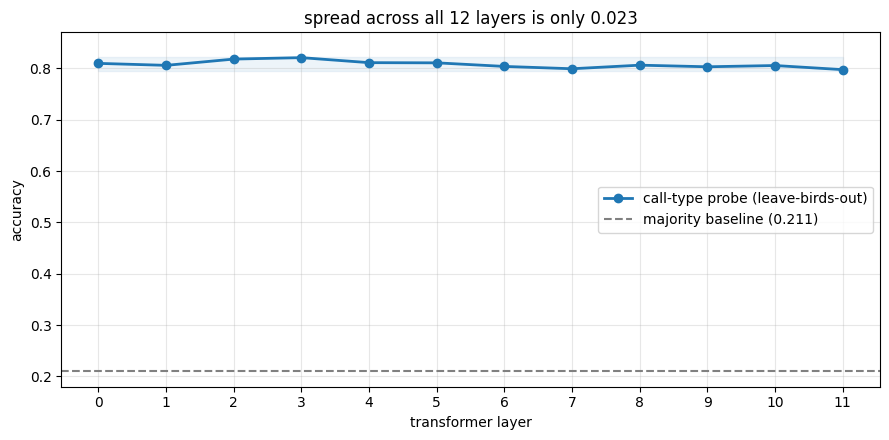

best  layer 3: 0.821
worst layer 11: 0.797
spread: 0.023


In [3]:
L  = [r[0] for r in rows]
acc = [r[1] for r in rows]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(L, acc, "o-", lw=2, label="call-type probe (leave-birds-out)")
ax.axhline(majority, ls="--", c="gray", label=f"majority baseline ({majority:.3f})")
ax.fill_between(L, min(acc) - .002, max(acc) + .002, alpha=.08, color="C0")
ax.set_xlabel("transformer layer"); ax.set_ylabel("accuracy"); ax.set_xticks(L)
ax.set_ylim(0.18, 0.87); ax.legend(loc="center right"); ax.grid(alpha=.3)
ax.set_title(f"spread across all 12 layers is only {max(acc)-min(acc):.3f}")
plt.tight_layout(); plt.show()

print(f"best  layer {best[0]}: {best[1]:.3f}")
print(f"worst layer {min(rows, key=lambda r: r[1])[0]}: {min(acc):.3f}")
print(f"spread: {max(acc)-min(acc):.3f}")

**This flatness is the honest headline.** Every layer lands between 0.797 and 0.821,
nearly four times the 0.211 baseline. So call-type information is present and linearly
readable — but it is spread evenly through the network rather than concentrated somewhere.

Compare that with the detection task (vocalization vs. background), which has a *shape*:

| layer | 0 | 1 | 2 | 3 | ... | 11 |
|---|---|---|---|---|---|---|
| detection AUC | **0.921** | 0.912 | 0.903 | 0.896 | ... | 0.883 |

Detection declines monotonically with depth — shallow layers keep the acoustic detail that
says "a sound happened here." Call type shows no such gradient. Treat "layer 3 is best" as a
weak preference, not a finding: a 0.024 spread across 12 layers on 2867 clips is well within
what resampling noise can produce.

## Where the errors are

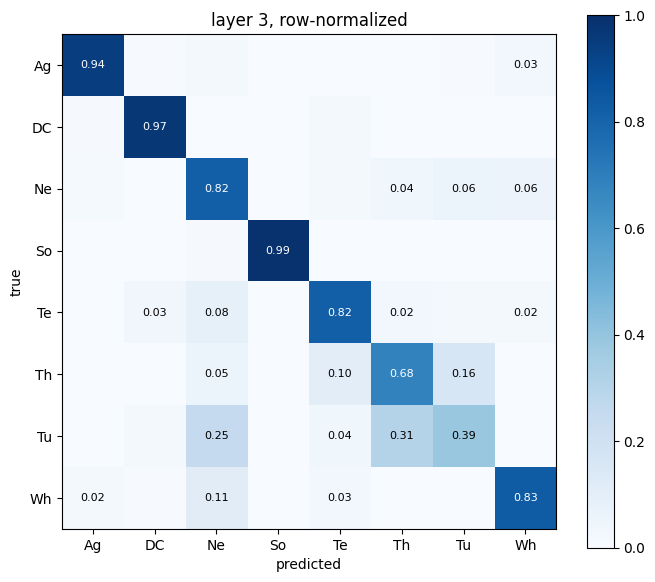

per-class recall:
  So: 0.990   (n=192)
  DC: 0.970   (n=605)
  Ag: 0.945   (n=200)
  Wh: 0.831   (n=172)
  Te: 0.818   (n=577)
  Ne: 0.817   (n=580)
  Th: 0.681   (n=301)
  Tu: 0.388   (n=240)


In [4]:
oof = best[3]
cm = confusion_matrix(y, oof, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"layer {best[0]}, row-normalized")
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm[i, j] > .02:
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > .5 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

print("per-class recall:")
for c, r in sorted(zip(classes, cm.diagonal()), key=lambda t: -t[1]):
    print(f"  {c}: {r:.3f}   (n={counts[list(classes).index(c)]})")

## Caveat you should carry into any use of these numbers

The curated clips evaluated here were part of the ~100 h corpus the model was pretrained on.
Pretraining was label-free, so the model cannot have memorized call-type *labels* — but it
has seen this audio, so absolute accuracy may be optimistic relative to a truly fresh
recording session.

What this does **not** affect: comparisons between layers, between runs, or against the
baselines, since every one of those sees exactly the same clips. The clean fix is a pretraining
holdout (retrain with these birds excluded), which has not been run yet.